In [1]:
library(future)

# plan("multicore", workers = 24) # Mac Pro 6.1
# plan(workers = 36) # iMac Pro 1.1
# plan("multicore", workers = 8) # 4 core Intel CPU and M1 have 8 threads
# plan("multicore", workers = 12) # 6 core Intel CPU has 12 threads
plan("multicore", workers = 10) # 10 core M1 Pro CPU has 10 threads

# Set RAM Size to 3/4 of total RAM

# options(future.globals.maxSize = 48000 * 1024^2) # Mac Pros have 64 Gb
options(future.globals.maxSize = 16000 * 1024^2) # iMacs and MacBook Pros have 16 Gb

future.seed=NULL # Removes future-generated statistical errors

library(Seurat)
library(BPCells)
library(dplyr)
library(fs)
library(Matrix)
library(ggplot2)
library(viridis)
library(harmony)

options(Seurat.object.assay.version = "v5")

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: viridisLite

Loading required package: Rcpp



# Preprocessing 

In [70]:
Seurat <- readRDS("Erythroid_Cells.rds")
Seurat

An object of class Seurat 
111998 features across 17557 samples within 3 assays 
Active assay: SCT (17572 features, 2924 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: RNA, Isoform
 3 dimensional reductions calculated: pca, mRNA_harmony, umap

Running SCTransform and PCA on the subset...

Warning message:
“Different cells and/or features from existing assay SCT”
Transposing data matrix

Initializing state using k-means centroids initialization

Harmony 1/10

Harmony 2/10

Harmony 3/10

Harmony 4/10

Harmony converged after 4 iterations



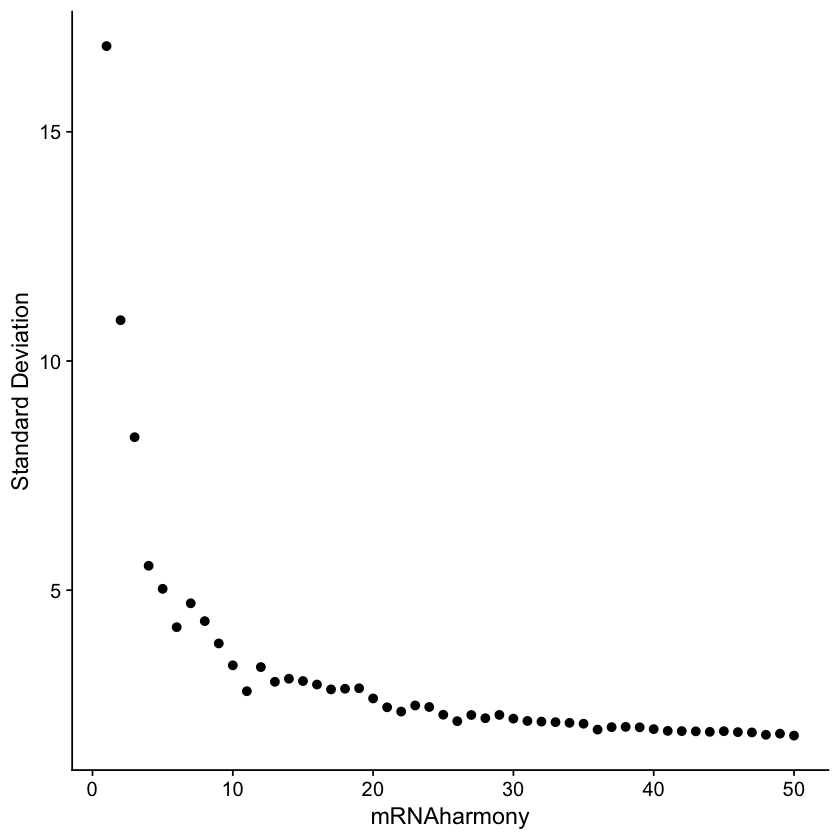

In [71]:
DefaultAssay(Seurat) <- "SCT"

message("Running SCTransform and PCA on the subset...")

Seurat <- SCTransform(Seurat, vst.flavor = "v2", verbose = FALSE)

Seurat <- RunPCA(Seurat, npcs = 50, verbose = FALSE)

Seurat <- RunHarmony(
  object = Seurat, 
  group.by.vars = "Batch",
  reduction = "pca", 
  assay.use = "SCT", 
  plot_convergence = FALSE, 
  project.dim = FALSE, 
  reduction.save = "mRNA_harmony"
)

ElbowPlot(Seurat, ndims = 50, reduction = "mRNA_harmony")

In [72]:
# UMAP
dims = 35

Seurat <- FindNeighbors(Seurat, dims = 1:dims
                        , reduction = "mRNA_harmony"
                       )
Seurat <- RunUMAP(Seurat, dims = 1:dims 
                 , reduction = "mRNA_harmony"
                 )

Computing nearest neighbor graph

Computing SNN

15:17:17 UMAP embedding parameters a = 0.9922 b = 1.112

15:17:17 Read 17557 rows and found 35 numeric columns

15:17:17 Using Annoy for neighbor search, n_neighbors = 30

15:17:17 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

15:17:18 Writing NN index file to temp file /var/folders/lk/54m90rgj1fqg895lxsgx1l180000gn/T//RtmpCBSof4/file9014438693ee

15:17:18 Searching Annoy index using 10 threads, search_k = 3000

15:17:19 Annoy recall = 100%

15:17:20 Commencing smooth kNN distance calibration using 10 threads
 with target n_neighbors = 30

15:17:20 Initializing from normalized Laplacian + noise (using RSpectra)

15:17:21 Commencing optimization for 200 epochs, with 803150 positive edges

15:17:21 Using rng type: pcg

1

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 17557
Number of edges: 699048

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8834
Number of communities: 19
Elapsed time: 2 seconds


Warning message:
“UNRELIABLE VALUE: One of the ‘future.apply’ iterations (‘future_lapply-1’) unexpectedly generated random numbers without declaring so. There is a risk that those random numbers are not statistically sound and the overall results might be invalid. To fix this, specify 'future.seed=TRUE'. This ensures that proper, parallel-safe random numbers are produced via a parallel RNG method. To disable this check, use 'future.seed = NULL', or set option 'future.rng.onMisuse' to "ignore". [future ‘future_lapply-1’ (fc6d7dec92f5c588123aa66368c3ac7d-110); on fc6d7dec92f5c588123aa66368c3ac7d@MacBook-Pro-Roman.local<36884>]”


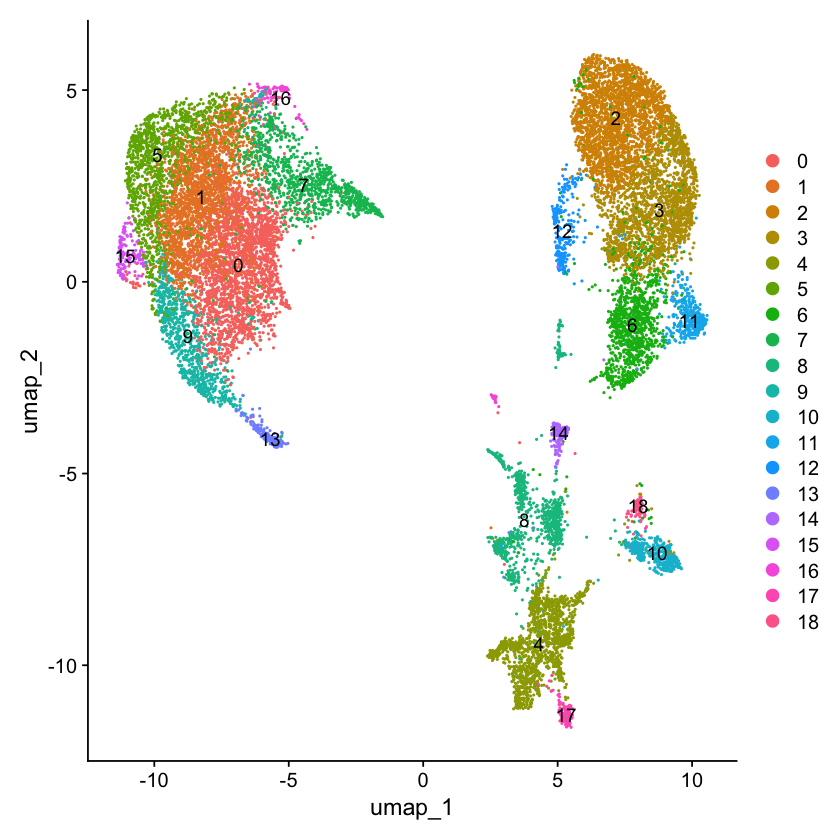

In [73]:
Seurat <- FindClusters(Seurat, resolution = 0.6)
DimPlot(Seurat, label=TRUE, reduction = "umap")

ggsave( 
  "Clusters.png",
  plot   = last_plot(),
  width  = 22,
  height = 18,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

In [74]:
library(dplyr)

DefaultAssay(Seurat) <- "SCT"

markers_rna <- FindAllMarkers(
  Seurat,
  only.pos        = TRUE,
  min.pct         = 0.25,
  logfc.threshold = 0.25,
  test.use        = "wilcox"
)

if (!"avg_log2FC" %in% colnames(markers_rna) && "avg_logFC" %in% colnames(markers_rna)) {
  markers_rna$avg_log2FC <- markers_rna$avg_logFC
}

top_rna <- markers_rna %>%
  filter(p_val_adj < 0.05) %>%
  group_by(cluster) %>%
  arrange(desc(avg_log2FC), .by_group = TRUE) %>%
  slice_head(n = 200) %>%
  ungroup()

write.csv(top_rna, file = "Significant_RNA_Ery_Markers_Top200.csv", row.names = FALSE)

Calculating cluster 0

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11

Calculating cluster 12

Calculating cluster 13

Calculating cluster 14

Calculating cluster 15

Calculating cluster 16

Calculating cluster 17

Calculating cluster 18



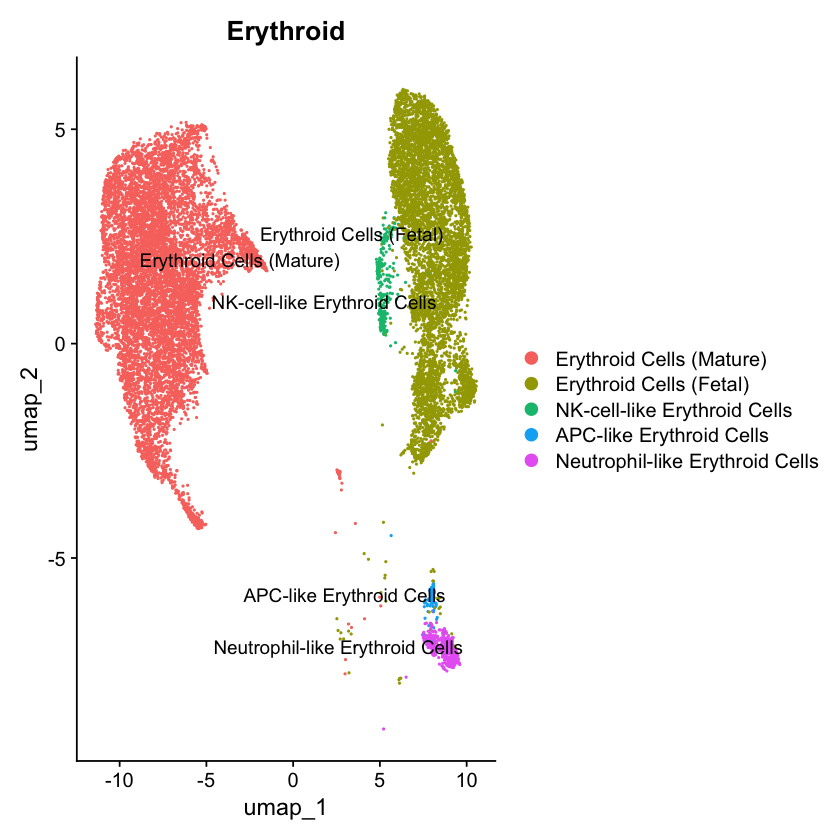

In [75]:
Idents(Seurat) <- "seurat_clusters"

Seurat <- RenameIdents(
  Seurat,
  # Mature Erythroid
  "15" = "Erythroid Cells (Mature)",
  "13" = "Erythroid Cells (Mature)",
  "9"  = "Erythroid Cells (Mature)",
  "1"  = "Erythroid Cells (Mature)",
  "0"  = "Erythroid Cells (Mature)",
  "5"  = "Erythroid Cells (Mature)",
  "7"  = "Erythroid Cells (Mature)",
  "16" = "Erythroid Cells (Mature)",
  
  # Fetal/Cycling/Primitive Erythroid
  "2"  = "Erythroid Cells (Fetal)",
  "3"  = "Erythroid Cells (Fetal)",
  "6"  = "Erythroid Cells (Fetal)",
  "11" = "Erythroid Cells (Fetal)",
  
  # The "Immune-like" Erythroid Subsets
  "12" = "NK-cell-like Erythroid Cells",
  "18" = "APC-like Erythroid Cells",
  "10" = "Neutrophil-like Erythroid Cells",
  
  # Structural / Non-blood (To be removed)
  "17" = "Neural / Neuroectoderm",
  "4"  = "Labyrinthine Mesenchyme",
  "8"  = "Epithelial / Trophoblast",
  "14" = "Spongiotrophoblasts"
)

Seurat$Erythroid <- Idents(Seurat)

Seurat_Clean <- subset(Seurat, idents = c(
  "Erythroid Cells (Mature)",
  "Erythroid Cells (Fetal)",
  "NK-cell-like Erythroid Cells",
  "APC-like Erythroid Cells",
  "Neutrophil-like Erythroid Cells"
))

DimPlot(Seurat_Clean, group.by = "Erythroid", label = TRUE, repel = TRUE)

In [76]:
Seurat <- Seurat_Clean

In [77]:
Seurat$UMAP_1 <- Embeddings(Seurat, "umap")[, 1]
Seurat$UMAP_2 <- Embeddings(Seurat, "umap")[, 2]

cells_to_keep <- WhichCells(Seurat, expression = !((UMAP_1 > -2.5  & UMAP_1 < 7) & (UMAP_2 > -15 & UMAP_2 < -2)))

Seurat <- Seurat[, cells_to_keep]

In [84]:
saveRDS(Seurat, file = "Erythroid_Cells.rds")

# Analysis

In [2]:
Seurat <- readRDS("Erythroid_Cells.rds")

In [76]:
erythroid_levels <- c(
    "Erythroid Cells (Mature)",
    "Erythroid Cells (Fetal)",
    "NK-cell-like Erythroid Cells",
    "APC-like Erythroid Cells",
    "Neutrophil-like Erythroid Cells"
)

Seurat$Erythroid <- factor(Seurat$Erythroid, levels = erythroid_levels)

Seurat$Erythroid <- droplevels(Seurat$Erythroid)

Idents(Seurat) <- "Erythroid"

table(Seurat$Erythroid)


       Erythroid Cells (Mature)         Erythroid Cells (Fetal) 
                           8352                            5752 
   NK-cell-like Erythroid Cells        APC-like Erythroid Cells 
                            252                             103 
Neutrophil-like Erythroid Cells 
                            418 

In [6]:
auc_raw_mat <- t(read.csv("pySCENIC-AUC-Raw.csv", row.names = 1, check.names = FALSE))
auc_bin_mat <- t(read.csv("pySCENIC-AUC-Binary.csv", row.names = 1, check.names = FALSE))

cells_in_subset <- colnames(Seurat)

auc_raw_sub <- auc_raw_mat[, cells_in_subset, drop = FALSE]
auc_bin_sub <- auc_bin_mat[, cells_in_subset, drop = FALSE]

rownames(auc_raw_sub) <- gsub("\\(\\+\\)", "", rownames(auc_raw_sub))
rownames(auc_bin_sub) <- gsub("\\(\\+\\)", "", rownames(auc_bin_sub))

Seurat[["AUC"]] <- CreateAssayObject(counts = auc_raw_sub)
Seurat[["AUC_Binary"]] <- CreateAssayObject(counts = auc_bin_sub)

names(Seurat)

[1] "RNA"          "Isoform"      "SCT"          "AUC"          "AUC_Binary"  
 [6] "SCT_nn"       "SCT_snn"      "pca"          "mRNA_harmony" "umap"

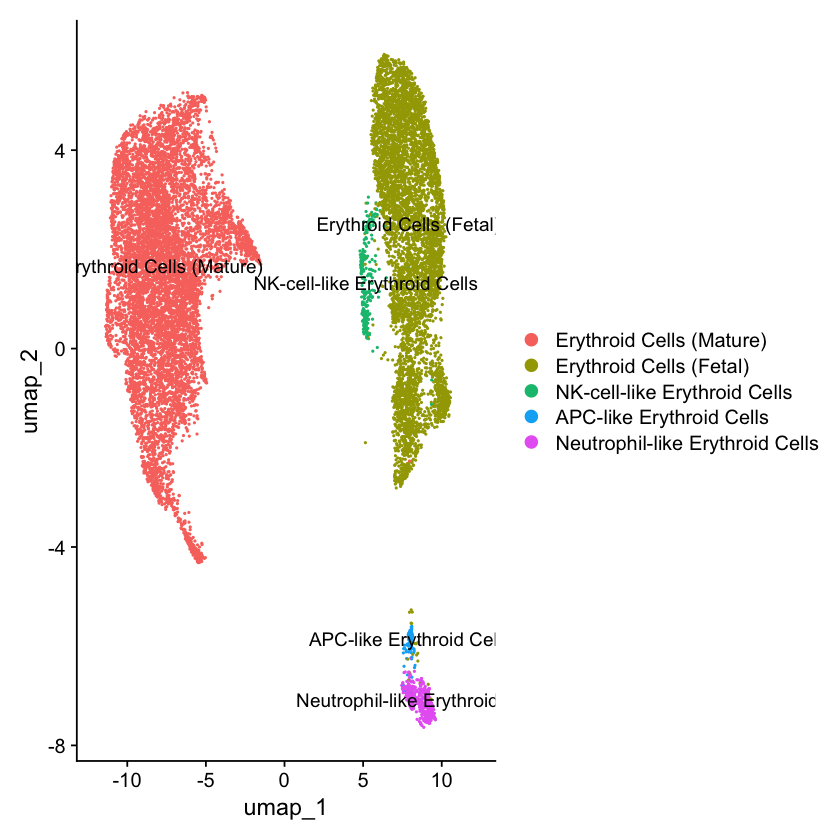

In [77]:
DimPlot(Seurat, label=TRUE, reduction = "umap") + xlim(-12, 12.2)

ggsave( 
  "Clusters.png",
  plot   = last_plot(),
  width  = 24.75,
  height = 18,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

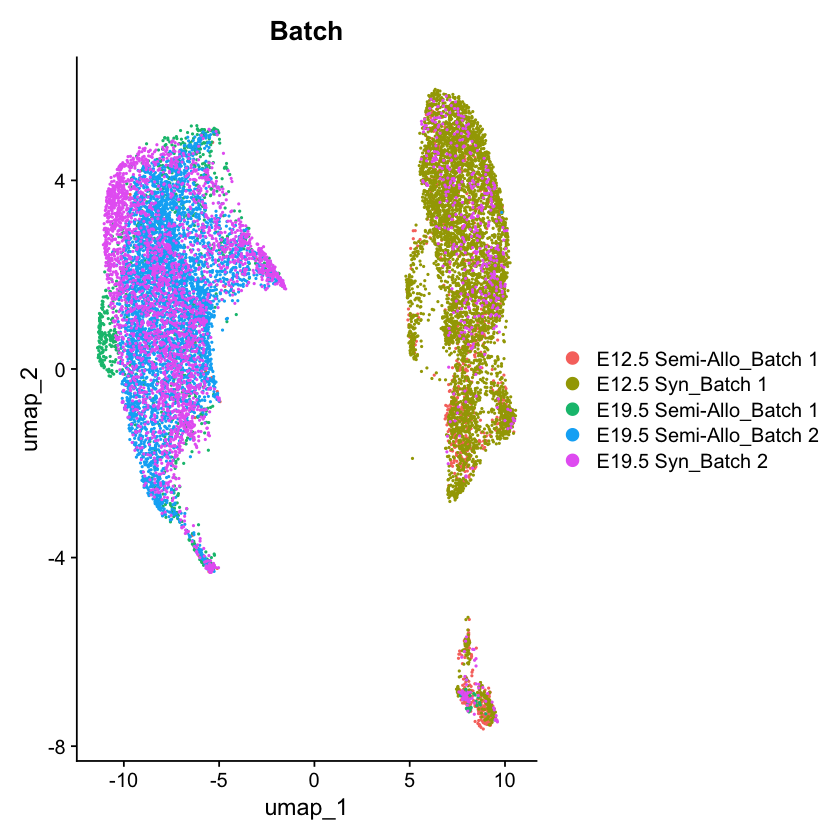

In [16]:
DimPlot(Seurat, group.by = "Batch", label = FALSE, repel = TRUE, reduction = "umap")

ggsave( 
  "Batch.png",
  plot   = last_plot(),
  width  = 23,
  height = 18,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

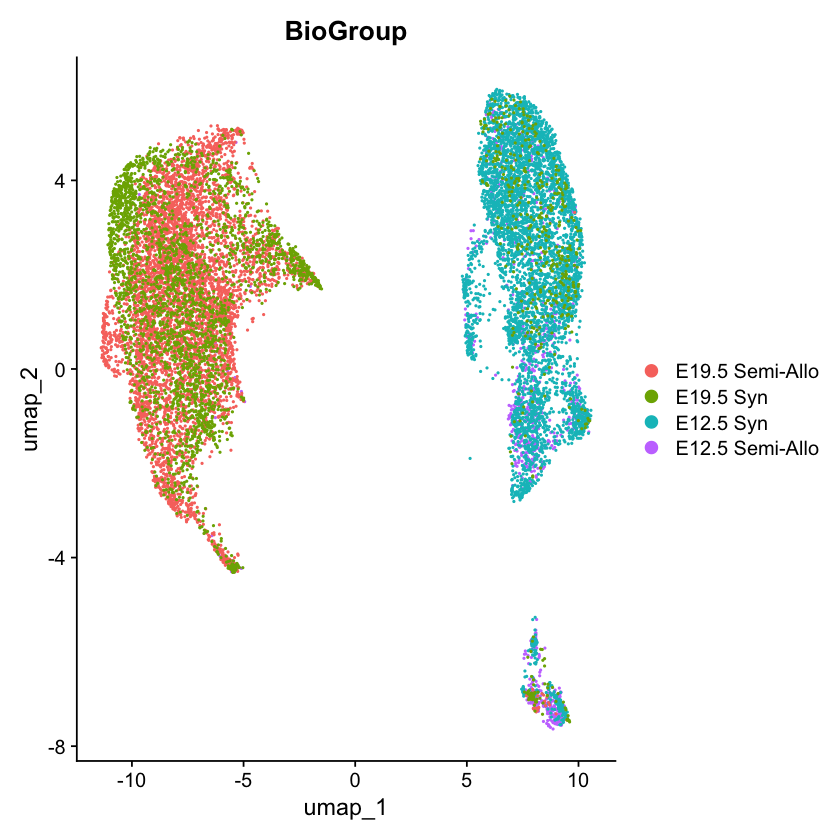

In [15]:
DimPlot(Seurat, group.by = "BioGroup", label = FALSE, repel = TRUE, reduction = "umap")

ggsave( 
  "BioGroup.png",
  plot   = last_plot(),
  width  = 22,
  height = 18,
  units  = "cm",
  dpi    = 600,
  limitsize = TRUE,
  bg     = "white"
)

In [50]:
library(dplyr)

DefaultAssay(Seurat) <- "SCT"

markers_rna <- FindAllMarkers(
  Seurat,
  only.pos        = TRUE,
  min.pct         = 0.25,
  logfc.threshold = 0.25,
  test.use        = "wilcox"
)

if (!"avg_log2FC" %in% colnames(markers_rna) && "avg_logFC" %in% colnames(markers_rna)) {
  markers_rna$avg_log2FC <- markers_rna$avg_logFC
}

top_rna <- markers_rna %>%
  filter(p_val_adj < 0.05) %>%
  group_by(cluster) %>%
  arrange(desc(avg_log2FC), .by_group = TRUE) %>%
  slice_head(n = 200) %>%
  ungroup()

write.csv(top_rna, file = "Significant_RNA_Ery_Cluster_Markers_Top200.csv", row.names = FALSE)

Calculating cluster Erythroid Cells (Mature)

Calculating cluster Erythroid Cells (Fetal)

Calculating cluster NK-cell-like Erythroid Cells

Calculating cluster APC-like Erythroid Cells

Calculating cluster Neutrophil-like Erythroid Cells



In [81]:
biogroup_order <- c(
  "E19.5 Semi-Allo", 
  "E19.5 Syn", 
  "E12.5 Syn", 
  "E12.5 Semi-Allo"
)

Seurat$BioGroup <- factor(
  Seurat$BioGroup, 
  levels = biogroup_order
)

levels(Seurat$BioGroup)

[1] "E19.5 Semi-Allo" "E19.5 Syn"       "E12.5 Syn"       "E12.5 Semi-Allo"

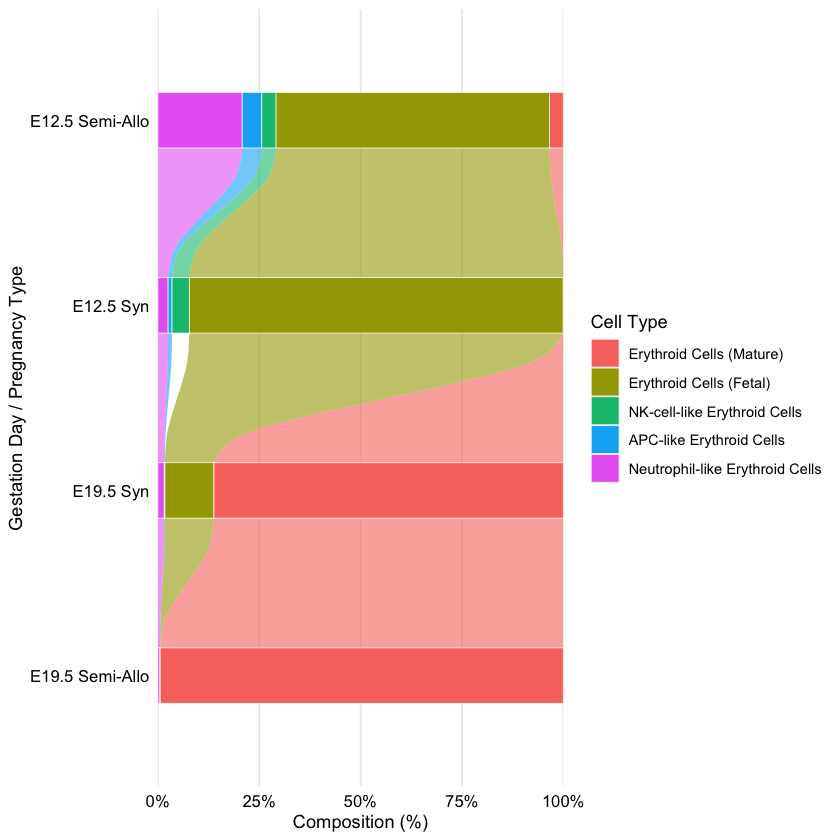

In [78]:
library(ggplot2)
library(ggalluvial)
library(dplyr)

plot_data <- Seurat@meta.data %>%
  group_by(BioGroup, Erythroid) %>%
  tally() %>%
  group_by(BioGroup) %>%
  mutate(pct = n / sum(n) * 100) %>%
  ungroup()

ggplot(plot_data, 
       aes(x = BioGroup, y = pct, fill = Erythroid, 
           stratum = Erythroid, alluvium = Erythroid)) +
  geom_flow(alpha = 0.6, width = 0.3) + 
  geom_stratum(width = 0.3, color = "white", size = 0.2) +
  scale_y_continuous(expand = c(0, 0), labels = function(x) paste0(x, "%")) +
  theme_minimal() +
  theme(
    panel.grid.major.y = element_blank(),
    panel.grid.minor = element_blank(),
    axis.text = element_text(color = "black", size = 10),
    legend.position = "right"
  ) +
  labs(x = "Gestation Day / Pregnancy Type", y = "Composition (%)", fill = "Cell Type") +
  coord_flip()

ggsave(
  "Horizontal_Alluvial_Wide.png",
  plot   = last_plot(),
  width  = 39,  
  height = 9.5,  
  units  = "cm",
  dpi    = 600,
  bg     = "white"
)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


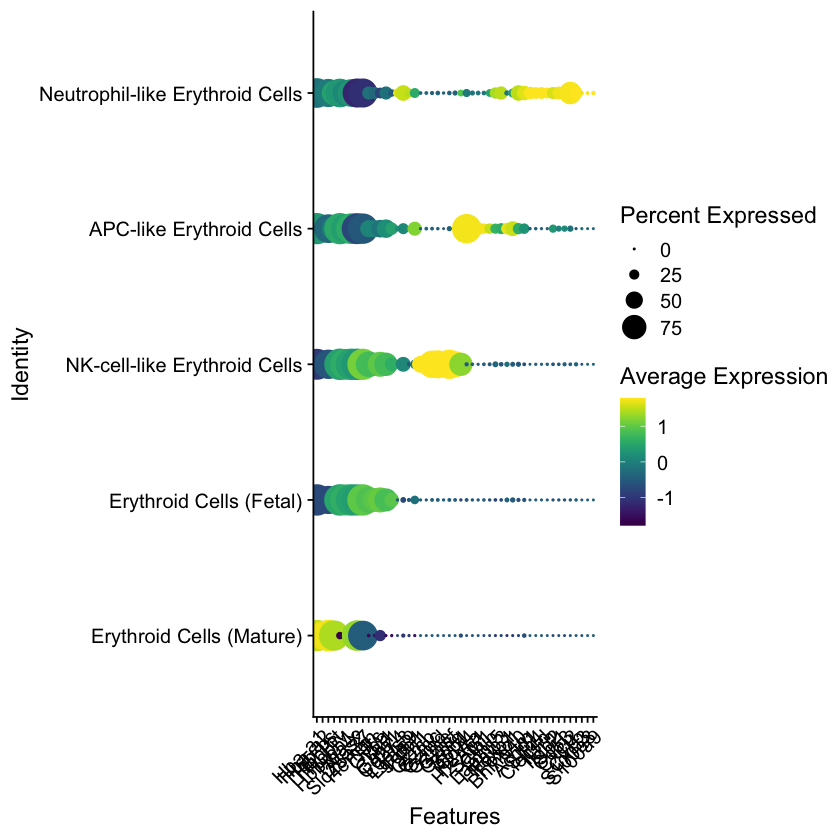

In [62]:
markers <- c(
  # Core Erythroid (Mature & Fetal)
  'Hba-a1', 'Hba-a2','Hbb-bs', 'Hbb-bt',          # Definitive/Mature
  'Hbb-y', 'Hbb-bh1', 'Hba-x',                    # Primitive/Fetal
  'Alas2', 'Slc25a37', 'Hemgn',                   # Heme 
  'Tfrc', 'Gypa', 'Tal1', 'Gata1',                # Other Maturation

  # Checkpoint & Immunomodulatory
  'Cd274', 'Lgals3', 'Lgals9', 'Tgfb1',            # Suppressive Environment
  
  # NK-cell-like Erythroid Cells 
  'Prf1', 'Gzmb', 'Gzmc', 'Gzmd', 'Gzme',         # Cytotoxic Granzyme Suite
  'Gzmf', 'Gzmg', 'Spp1',                         # NK/uNK associated
  
  # APC-like Erythroid Cells 
  'Cd74', 'H2-Aa', 'H2-Ab1',                      # MHC-II
  'Satb1', 'Cytip', 'Laptm5', 'Tnfaip3',          # Immune Signaling
  'Foxo1', 'Foxp1', 'Bhlhe40',                    # APC-linked TFs
  'Vim',                                          # Progenitor Marker
  
  # Neutrophil-like Erythroid Cells 
  'Acod1', 'Slfn4', 'Clec4d', 'Il1rn',            # Neutrophil/Myeloid specific
  'Itgb2', 'Spi1', 'Cd53',                        # Myeloid Markers
  'Cxcl2', 'Il1b','Cxcl3', 'S100a8', 'S100a9'     # Inflammatory/Alarmin
)

DotPlot(
    Seurat,
    features = unique(markers),
    dot.scale = 8, 
    assay = "SCT"
) + 
  scale_color_viridis() + 
  RotatedAxis()

ggsave(
  filename = "DotPlot.jpeg", 
  plot = last_plot(),
  width = 20, 
  height = 4.5, 
  dpi = 600  
)

In [ ]:
qc_plot <- VlnPlot(
  Seurat, 
  features = c("nFeature_RNA", "nCount_RNA",'percent.mt','percent.hb'), 
  ncol = 2, 
  pt.size = 0
)

ggsave(
  filename = "QC_Check.png", 
  plot = qc_plot,
  width = 15, 
  height = 18,   
  dpi = 600,
  bg = "white" 
)

# TF activity analysis

In [ ]:
DefaultAssay(Seurat) <- "AUC"
Seurat <- ScaleData(Seurat, features = rownames(Seurat))
Idents(Seurat) <- "Erythroid" 
Seurat$Erythroid <- droplevels(Seurat$Erythroid)

In [19]:
target_tfs <- c("Gata1", "Klf1","Ikzf1",
                "Cebpe", "Cebpa", "Gfi1", "Spi1",    # Neutrophils
                "Irf8", "Irf4", "Mafb", "Nfkb1",     # APCs (Macs/DCs)
                "Eomes", "Tbx21", "Id2", "Stat4"     # NK Cells
)

for (tf in target_tfs) {
  
  message(sprintf("Generating co-visualization for Tal1 and %s...", tf))
  
  if (tf %in% rownames(Seurat)) {
    
    p <- FeaturePlot(Seurat, 
                     features = c("Tal1", tf), 
                     blend = TRUE, 
                     cols = c("lightgrey", "#ff0000", "#0000ff"), # Red and Blue
                     slot = "scale.data",
                     pt.size = 0.5,
                     order = TRUE)
    
    # Save the plot
    jpeg(sprintf("CoVizTal1_%s_AUC.jpg", tf), width = 18.5, height = 5, units = "in", res = 600)
    print(p)
    dev.off()
    
  } else {
    warning(sprintf("TF %s not found in the AUC assay. Skipping...", tf))
  }
}

Generating co-visualization for Tal1 and Gata1...

Generating co-visualization for Tal1 and Klf1...

Generating co-visualization for Tal1 and Ikzf1...

Generating co-visualization for Tal1 and Cebpe...

Warning message:
“TF Cebpe not found in the AUC assay. Skipping...”
Generating co-visualization for Tal1 and Cebpa...

Generating co-visualization for Tal1 and Gfi1...

Warning message:
“TF Gfi1 not found in the AUC assay. Skipping...”
Generating co-visualization for Tal1 and Spi1...

Generating co-visualization for Tal1 and Irf8...

Generating co-visualization for Tal1 and Irf4...

Generating co-visualization for Tal1 and Mafb...

Generating co-visualization for Tal1 and Nfkb1...

Generating co-visualization for Tal1 and Eomes...

Generating co-visualization for Tal1 and Tbx21...

Warning message:
“TF Tbx21 not found in the AUC assay. Skipping...”
Generating co-visualization for Tal1 and Id2...

Warning message:
“TF Id2 not found in the AUC assay. Skipping...”
Generating co-visualizati

In [61]:
library(ComplexHeatmap)
library(circlize)
library(scales)

level_order <- c(
  "Erythroid Cells (Mature)",
  "Erythroid Cells (Fetal)",
  "NK-cell-like Erythroid Cells",
  "APC-like Erythroid Cells",
  "Neutrophil-like Erythroid Cells"
)

Seurat_sub <- subset(Seurat, idents = level_order)
Seurat_sub$Erythroid <- factor(as.character(Seurat_sub$Erythroid), levels = level_order)
Idents(Seurat_sub) <- "Erythroid"

Seurat_plot_obj <- subset(Seurat_sub, downsample = 150)

features_to_plot <- intersect(target_tfs, rownames(Seurat_plot_obj[["AUC"]]))
plot_mat <- as.matrix(GetAssayData(Seurat_plot_obj, assay = "AUC", layer = "scale.data")[features_to_plot, ])
cluster_anno <- Seurat_plot_obj$Erythroid

cluster_colors <- setNames(hue_pal()(length(level_order)), level_order)

top_ann <- HeatmapAnnotation(
  Cluster = cluster_anno,
  col = list(Cluster = cluster_colors),
  annotation_legend_param = list(
    Cluster = list(
      title = "Cluster",
      title_gp = gpar(fontsize = 12, fontfamily = "sans"),
      labels_gp = gpar(fontsize = 10, fontfamily = "sans")
    )
  ),
  show_annotation_name = FALSE
)

jpeg("Regulon_HM.jpg", width = 16, height = 6, units = "in", res = 600)

Heatmap(plot_mat, 
        name = "Z-score",
        
        # BWR Color Map: Blue (Low) -> White (Mean) -> Red (High)
        col = colorRamp2(c(-2, 0, 2), c("blue", "white", "red")), 
        
        # CLUSTERING LOGIC
        column_split = cluster_anno,    # Splits the heatmap by your defined levels
        cluster_column_slices = FALSE,  # FORCES the Mature -> Fetal -> Hybrid order
        cluster_columns = TRUE,         # Clusters cells WITHIN each of those slices
        show_column_dend = FALSE,       # Removes the top dendrogram
        
        cluster_rows = TRUE,            # Clusters the TFs by similarity
        show_row_dend = TRUE,           # Shows the TF hierarchy on the left
        
        # TITLES & LABELS
        column_title_gp = gpar(fontsize = 12, fontfamily = "sans"),
        column_title_rot = 45,
        
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 12, fontface = "plain", fontfamily = "sans"),
        
        # SEURAT-LIKE LEGEND
        heatmap_legend_param = list(
          title = "Z-score",
          title_gp = gpar(fontsize = 12, fontfamily = "sans"),
          labels_gp = gpar(fontsize = 10, fontfamily = "sans"),
          legend_height = unit(4, "cm"),
          grid_width = unit(4, "mm")
        ),
        
        # CLEANUP
        show_column_names = FALSE,
        column_gap = unit(1, "mm"),
        border = FALSE,
        top_annotation = top_ann
)

dev.off()

agg_record_637014278 
                   2

In [64]:
DefaultAssay(Seurat) <- "SCT"

In [103]:
ery_genes <- list(c('Alas2', 'Slc25a37', 'Hemgn',
                    'Tfrc', 'Gypa', 'Tal1', 'Gata1'))

nk_genes <- list(c("Eomes", "Tbx21", "Nkg7",  "Klrd1",'Spp1',
                   'Prf1', 'Gzmb', 'Gzmc', 'Gzmd', 'Gzme','Gzmf', 'Gzmg'))

apc_genes <- list(c("Irf8", "Cd74", "H2-Ab1", "H2-Aa", "Cd80","Cd86", "Ciita"))

neutro_genes <- list(c("S100a8", "S100a9", "Retnlg", "Ly6g", "Mpo", "Camp"))

#Add Module Scores
Seurat <- AddModuleScore(Seurat, features = ery_genes, name = "ErythroidScore")
Seurat <- AddModuleScore(Seurat, features = nk_genes, name = "NK-cellScore")
Seurat <- AddModuleScore(Seurat, features = apc_genes, name = "APCScore")
Seurat <- AddModuleScore(Seurat, features = neutro_genes, name = "NeutrophilScore")

print(grep("Score", colnames(Seurat@meta.data), value = TRUE))

Warning message:
“The following features are not present in the object: Ly6g, Camp, not searching for symbol synonyms”


 [1] "Doublet_Score"    "EryScore1"        "ImmuneScore1"     "Ery-Score1"      
 [5] "NK-Score1"        "APC-Score1"       "Neutro-Score1"    "ErythroidScore1" 
 [9] "NKScore1"         "APCScore1"        "NeutrophilScore1" "NK-cellScore1"   
[13] "APCsScore1"      


In [104]:
library(ggplot2)

df <- Seurat@meta.data

# Define the X-axis (The Erythroid baseline)
x_axis <- "ErythroidScore1"

# Define the 3 Y-axes (The Immune programs)
y_axes <- c("NK-cellScore1", "APCScore1", "NeutrophilScore1")

# Ensure Erythroid factor levels are exactly as you set them
# level_order <- c("Erythroid Cells (Mature)", "Erythroid Cells (Fetal)", ...)

for (y_var in y_axes) {
  
  message(sprintf("Generating plot: %s vs %s", x_axis, y_var))
  
  # Clean name for title/labels (removes the '1')
  clean_name <- gsub("Score1", "", y_var)
  
  p <- ggplot(df, aes(x = .data[[x_axis]], y = .data[[y_var]], color = Erythroid)) +
    geom_point(size = 1, alpha = 0.6) +
    theme_classic() +
    # Crosshairs to define the "Dual-Program" quadrant
    geom_vline(xintercept = 0, linetype = "dashed", color = "grey") +
    geom_hline(yintercept = 0, linetype = "dashed", color = "grey") +
    labs(
      x = "Erythroid Program Score",
      y = paste(clean_name, "Program Score"),
      color = "Cluster",
      title = paste("Erythroid vs.", clean_name,"Co-activation")
    ) +
    scale_color_manual(values = scales::hue_pal()(length(levels(df$Erythroid))))

  # Save with unique filenames
  ggsave(
    filename = paste0("ProgramPlot_", clean_name, ".png"),
    plot = p,
    width = 18,
    height = 12,
    units = "cm",
    dpi = 600,
    bg = "white"
  )
}

Generating plot: ErythroidScore1 vs NK-cellScore1

Generating plot: ErythroidScore1 vs APCScore1

Generating plot: ErythroidScore1 vs NeutrophilScore1

